In [23]:
#%cd      /media/volume/NOCOS_WRK/ridge  #  change working directory 
NOCOSDIR='/home/ubuntu/NOCOS'
import os
os.chdir("/media/volume/NOCOS_WRK/ridge")
print(os.getcwd())  # where are we ?


/media/volume/NOCOS_WRK/ridge


In [51]:
import xarray as xr
url = "https://cacheb.dcms.destine.eu/d1-climate-dt/ScenarioMIP-SSP3-7.0-IFS-NEMO-0001-high-o2d-v0.zarr"
ds = xr.open_dataset(
    url, 
    chunks={}, 
    engine="zarr", 
    storage_options={"client_kwargs": {"trust_env": True}}
) #[["avg_siconc", "avg_sithick"]]
ds

<xarray.Dataset> Size: 4TB
Dimensions:       (time: 3653, latitude: 4096, longitude: 8193)
Coordinates:
  * latitude      (latitude) float64 33kB -90.0 -89.96 -89.91 ... 89.96 90.0
  * longitude     (longitude) float64 66kB -180.0 -180.0 -179.9 ... 180.0 180.0
    oceanSurface  float64 8B ...
    step          timedelta64[ns] 8B ...
  * time          (time) datetime64[ns] 29kB 2020-01-01 ... 2029-12-31
Data variables:
    avg_siconc    (time, latitude, longitude) float32 490GB dask.array<chunksize=(60, 256, 256), meta=np.ndarray>
    avg_sithick   (time, latitude, longitude) float32 490GB dask.array<chunksize=(60, 256, 256), meta=np.ndarray>
    avg_siue      (time, latitude, longitude) float32 490GB dask.array<chunksize=(60, 256, 256), meta=np.ndarray>
    avg_sivn      (time, latitude, longitude) float32 490GB dask.array<chunksize=(60, 256, 256), meta=np.ndarray>
    avg_sivol     (time, latitude, longitude) float32 490GB dask.array<chunksize=(60, 256, 256), meta=np.ndarray>
    avg_sos       (time, latitude, longitude) float32 490GB dask.array<chunksize=(60, 256, 256), meta=np.ndarray>
    avg_tos       (time, latitude, longitude) float32 490GB dask.array<chunksize=(60, 256, 256), meta=np.ndarray>
    avg_zos       (time, latitude, longitude) float32 490GB dask.array<chunksize=(60, 256, 256), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            2
    GRIB_subCentre:          1003
    history:                 2024-05-30T05:51 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

In [34]:

# Rename variables to 'sic' and 'sit'
ds2 = ds.rename({"avg_siconc": "sic", "avg_sithick": "sit"})
ds2

<xarray.Dataset> Size: 981GB
Dimensions:       (time: 3653, latitude: 4096, longitude: 8193)
Coordinates:
  * latitude      (latitude) float64 33kB -90.0 -89.96 -89.91 ... 89.96 90.0
  * longitude     (longitude) float64 66kB -180.0 -180.0 -179.9 ... 180.0 180.0
    oceanSurface  float64 8B ...
    step          timedelta64[ns] 8B ...
  * time          (time) datetime64[ns] 29kB 2020-01-01 ... 2029-12-31
Data variables:
    sic           (time, latitude, longitude) float32 490GB dask.array<chunksize=(60, 256, 256), meta=np.ndarray>
    sit           (time, latitude, longitude) float32 490GB dask.array<chunksize=(60, 256, 256), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            2
    GRIB_subCentre:          1003
    history:                 2024-05-30T05:51 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

In [46]:
import sys
import os
NOCOSDIR='/home/ubuntu/NOCOS'
# Define the absolute or relative path to the ridging directory
ridging_path =f"{NOCOSDIR}/applications/NOCOS_DMI_ridfork/ridging/"
# Add the path to sys.path
sys.path.append(os.path.abspath(ridging_path))
# Now you can import the modules
from read_config import read_configfile

#import read_ice_data
#import ridg_engine_NOCOS
cdir='/home/ubuntu/NOCOS/notebooks/rid/'
configs=read_configfile(f"{cdir}/config_ridg_calc_climdt.yml")

ds2 = ds.rename({"avg_siconc": "sic", "avg_sithick": "sit"});
icedata=ds2;
icedata=icedata.sel(latitude=slice(53, 66), longitude=slice(10, 30))
from calculate_RID import calc_RID_intcat
ridg_data=calc_RID_intcat(icedata,configs)
ridg_data

# Example usage
#config = read_config.load_config("config_ridg_calc_REF.yml")  # Assuming a function like this exists
#data = read_ice_data.load_ice_data("some_data_file.nc")  # Example function


These are the configurations you have chosen:
{'ice_filename': '/home/ilja/hpcshare/nemo_est/out_ice/N_run7_ice.selgor.mergetime*.nc', 'coordinates': {'ncat': 15, 'ncatnl': 5, 'ncat_name': 'ncatice', 'time_name': 'time', 'lat_name': 'x', 'lon_name': 'y'}, 'variables': {'siconc_name': 'icefrac', 'sithick_name': 'icethic', 'sivol_name': None, 'siitdconc_name': 'iceconc_cat', 'siitdthick_name': 'icethic_cat', 'siitdvol_name': None, 'siage_name': None, 'sisali_name': None}, 'RIDGE_method': {'Lthickconc': True, 'Ldthick': False, 'Ldproc': False}, 'sel': {'t1': datetime.date(2011, 1, 1), 't2': datetime.date(2011, 4, 1), 'x1': 1, 'x2': 151, 'y1': 1, 'y2': 181}, 'output': {'filename_automatic': True, 'filename': 'test_output_rid', 'output_folder': '.', 'title': 'Ridging Index Outcome (Ridging) calculated from  XX'}, 'multiCAT': True}



<xarray.DataArray 'sit' (latitude: 296, longitude: 455)> Size: 539kB
dask.array<truediv, shape=(296, 455), dtype=float32, chunksize=(222, 256), chunktype=numpy.ndarray>
Coordinates:
  * latitude      (latitude) float64 2kB 53.03 53.08 53.12 ... 65.91 65.96 66.0
  * longitude     (longitude) float64 4kB 10.02 10.06 10.11 ... 29.93 29.97
    oceanSurface  float64 8B 0.0
    step          timedelta64[ns] 8B 1 days

In [47]:
print(ridg_data)

<xarray.DataArray 'sit' (latitude: 296, longitude: 455)> Size: 539kB
dask.array<truediv, shape=(296, 455), dtype=float32, chunksize=(222, 256), chunktype=numpy.ndarray>
Coordinates:
  * latitude      (latitude) float64 2kB 53.03 53.08 53.12 ... 65.91 65.96 66.0
  * longitude     (longitude) float64 4kB 10.02 10.06 10.11 ... 29.93 29.97
    oceanSurface  float64 8B 0.0
    step          timedelta64[ns] 8B 1 days


<xarray.DataArray 'sit' (latitude: 296, longitude: 455)> Size: 539kB
dask.array<truediv, shape=(296, 455), dtype=float32, chunksize=(222, 256), chunktype=numpy.ndarray>
Coordinates:
  * latitude      (latitude) float64 2kB 53.03 53.08 53.12 ... 65.91 65.96 66.0
  * longitude     (longitude) float64 4kB 10.02 10.06 10.11 ... 29.93 29.97
    oceanSurface  float64 8B 0.0
    step          timedelta64[ns] 8B 1 days


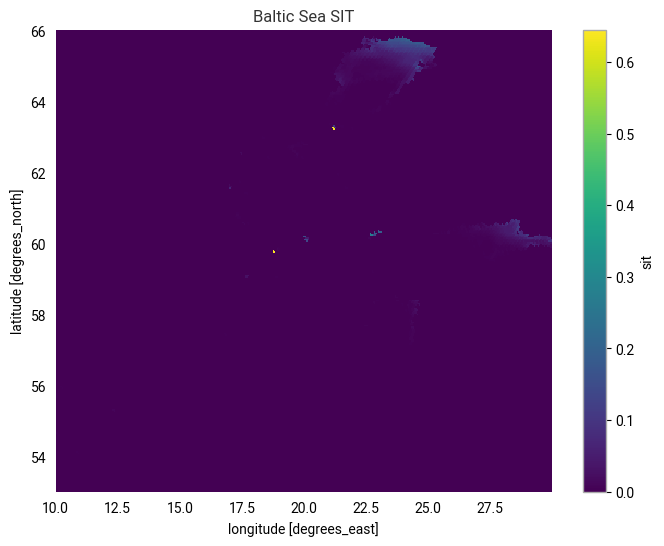

In [48]:
import xarray as xr
import matplotlib.pyplot as plt

# Subset the data for the Baltic Sea region.
# Adjust the coordinate ranges as needed.
baltic = ridg_data;

# Check the subset to confirm non-empty dimensions.
print(baltic)

# Plot the subset
plt.figure(figsize=(8, 6))
baltic.plot()  # This uses xarray's built-in plotting (usually pcolormesh)
plt.title("Baltic Sea SIT")
plt.show()


<xarray.DataArray 'sit' (latitude: 296, longitude: 455)> Size: 539kB
dask.array<truediv, shape=(296, 455), dtype=float32, chunksize=(222, 256), chunktype=numpy.ndarray>
Coordinates:
  * latitude      (latitude) float64 2kB 53.03 53.08 53.12 ... 65.91 65.96 66.0
  * longitude     (longitude) float64 4kB 10.02 10.06 10.11 ... 29.93 29.97
    oceanSurface  float64 8B 0.0
    step          timedelta64[ns] 8B 1 days


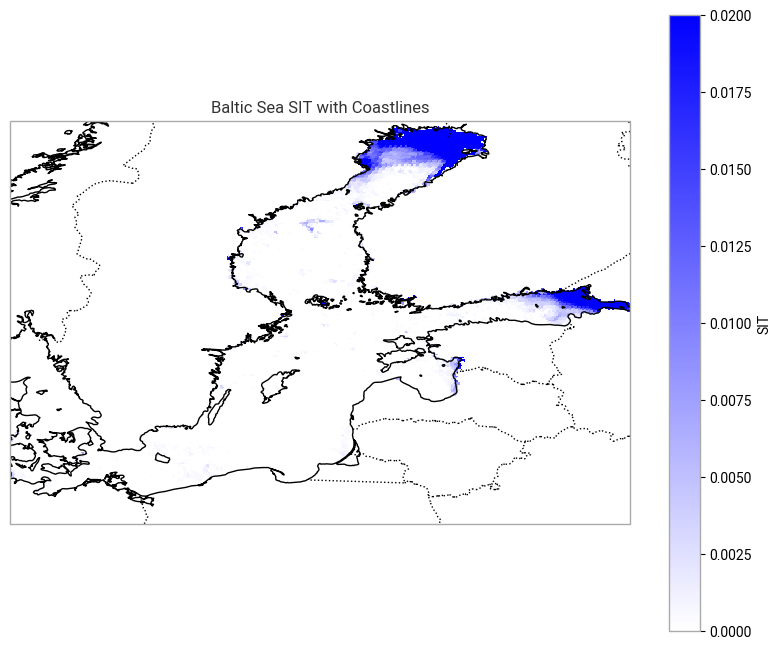

In [49]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LinearSegmentedColormap

# Define a custom colormap from white to blue
custom_cmap = LinearSegmentedColormap.from_list('white_blue', ['white', 'blue'])

# Subset the data for the Baltic Sea region.
# Adjust latitude and longitude bounds as needed.
baltic = ridg_data.sel(latitude=slice(53, 66), longitude=slice(10, 30))
print(baltic)  # Confirm the subset dimensions

# Create a plot using Cartopy with PlateCarree projection.
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add coastlines and borders for context.
ax.coastlines(resolution='10m')
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Plot the data using pcolormesh.
# The transform=ccrs.PlateCarree() indicates that the data is in lat/lon coordinates.
mesh = ax.pcolormesh(baltic.longitude, baltic.latitude, baltic.values,
                     transform=ccrs.PlateCarree(), cmap=custom_cmap,vmin=0,vmax=0.02)

# Add a colorbar.
plt.colorbar(mesh, ax=ax, orientation='vertical', label='SIT')

# Set a title.
ax.set_title("Baltic Sea SIT with Coastlines")

plt.show()


KeyError: 'ncat'